<a href="https://colab.research.google.com/github/RMoulla/IA_Reims/blob/main/TP_CIFAR10_CNN_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP — Classification d’images avec un CNN sur CIFAR-10 avec PyTorch

Dans ce TP, nous allons aborder un exemple de classification d'images avec un modèle CNN. Celui-ci permet de :

* Comprendre la structure d’un problème de classification d’images

* Manipuler le dataset CIFAR-10

* Implémenter un réseau de neurones convolutif (CNN) simple en PyTorch

* Mettre en place une boucle d’entraînement propre (train / validation)

* Interpréter les métriques : loss et accuracy

* Analyser qualitativement les prédictions d’un modèle


Le jeu de données CIFAR-10 est un jeu de données classique en vision par ordinateur.

Il contient 60 000 images couleur réparties sur 10 classes :

* airplane

* automobile

* bird

* cat

* deer

* dog

* frog

* horse

* ship

* truck

Les images sont de taille 32×32 pixels

## 0) Chargement des librairies nécessaires

In [ ]:
import os
import time
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt


In [ ]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## 1) Hyperparamètres

In [ ]:
@dataclass
class Config:
    data_dir: str = "./data"
    batch_size: int = 128
    num_workers: int = 2
    lr: float = 1e-3
    weight_decay: float = 0.0
    epochs: int = 10
    seed: int = 42

cfg = Config()
cfg


Config(data_dir='./data', batch_size=128, num_workers=2, lr=0.001, weight_decay=0.0, epochs=10, seed=42)

## 2) Dataset + DataLoaders (CIFAR-10)
- Images 32×32×3, 10 classes
- Préprocessing minimal : `ToTensor()` + normalisation


In [ ]:
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std  = (0.2470, 0.2435, 0.2616)

train_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])

test_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])


In [ ]:
train_ds = datasets.CIFAR10(root=cfg.data_dir, train=True, download=True, transform=train_tfms)
test_ds  = datasets.CIFAR10(root=cfg.data_dir, train=False, download=True, transform=test_tfms)

classes = train_ds.classes
len(train_ds), len(test_ds), classes


100%|██████████| 170M/170M [00:03<00:00, 48.9MB/s]


(50000,
 10000,
 ['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck'])

In [ ]:
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True
)


## 3) Visualisation rapide

In [ ]:
def denormalize(x: torch.Tensor, mean=cifar10_mean, std=cifar10_std) -> torch.Tensor:
    mean = torch.tensor(mean).view(3,1,1)
    std = torch.tensor(std).view(3,1,1)
    return x * std + mean

images, labels = next(iter(train_loader))
images.shape, labels.shape


(torch.Size([128, 3, 32, 32]), torch.Size([128]))

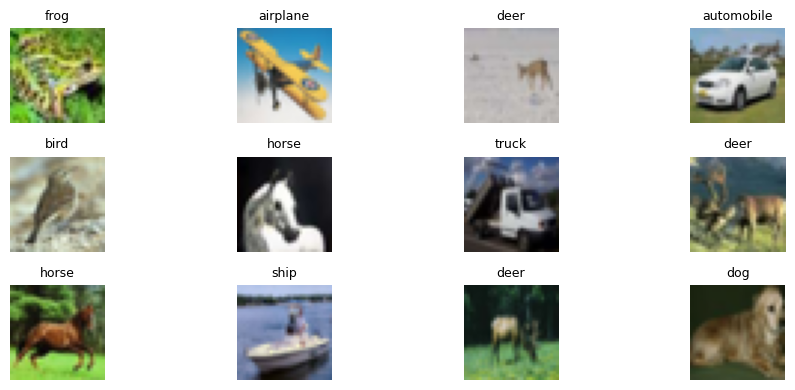

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(12):
    plt.subplot(3, 4, i+1)
    img = denormalize(images[i]).clamp(0, 1)
    plt.imshow(img.permute(1,2,0))
    plt.title(classes[labels[i].item()], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 4) Modèle CNN
3 blocs Conv-ReLU-MaxPool puis un petit MLP.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32x32
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             # 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 16x16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             # 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 8x8
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             # 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes=10).to(device)
model


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)

## 5) Loss + Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)


## 6) Boucles train / eval

In [ ]:
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)

    return total_loss / total, correct / total


In [ ]:
def train_one_epoch(model: nn.Module, loader: DataLoader, criterion: nn.Module, optimizer: optim.Optimizer, device: torch.device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)

    return total_loss / total, correct / total


## 7) Entraînement

In [ ]:
history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
}

best_test_acc = 0.0
best_path = "best_cifar10_cnn.pt"

for epoch in range(1, cfg.epochs + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), best_path)

    dt = time.time() - t0
    print(
        f"Epoch {epoch:02d}/{cfg.epochs} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"test loss {test_loss:.4f} acc {test_acc:.4f} | "
        f"{dt:.1f}s"
    )

print("Best test acc:", best_test_acc)


Epoch 01/10 | train loss 1.4112 acc 0.4894 | test loss 1.0984 acc 0.6075 | 15.3s
Epoch 02/10 | train loss 0.9779 acc 0.6552 | test loss 0.9576 acc 0.6772 | 14.4s
Epoch 03/10 | train loss 0.7938 acc 0.7218 | test loss 0.8092 acc 0.7249 | 15.3s
Epoch 04/10 | train loss 0.6600 acc 0.7687 | test loss 0.7579 acc 0.7394 | 15.7s
Epoch 05/10 | train loss 0.5591 acc 0.8041 | test loss 0.6992 acc 0.7630 | 14.8s
Epoch 06/10 | train loss 0.4747 acc 0.8330 | test loss 0.7254 acc 0.7562 | 15.2s
Epoch 07/10 | train loss 0.3892 acc 0.8631 | test loss 0.7498 acc 0.7633 | 15.4s
Epoch 08/10 | train loss 0.3131 acc 0.8919 | test loss 0.8344 acc 0.7490 | 15.5s
Epoch 09/10 | train loss 0.2482 acc 0.9125 | test loss 0.8350 acc 0.7600 | 15.6s
Epoch 10/10 | train loss 0.1945 acc 0.9319 | test loss 0.9304 acc 0.7606 | 14.4s
Best test acc: 0.7633


## 8) Courbes

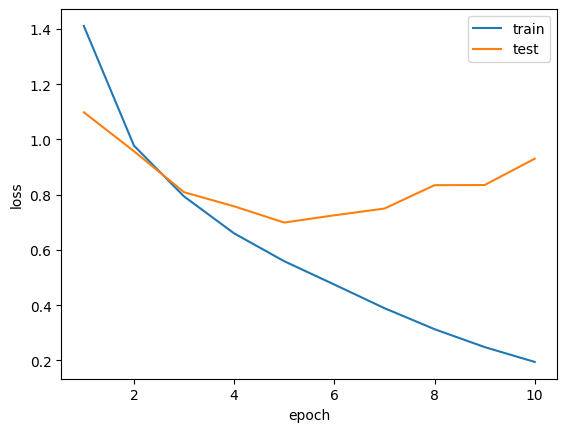

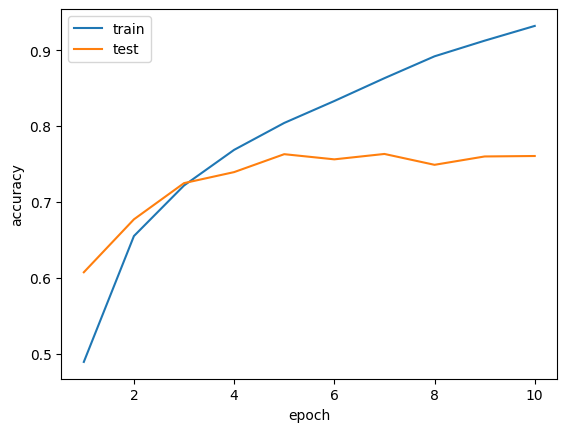

In [ ]:
epochs = np.arange(1, cfg.epochs + 1)

plt.figure()
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["test_acc"], label="test")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()


## 9) Quelques prédictions

In [ ]:
best_model = SimpleCNN(num_classes=10).to(device)
best_model.load_state_dict(torch.load(best_path, map_location=device))
best_model.eval()


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)

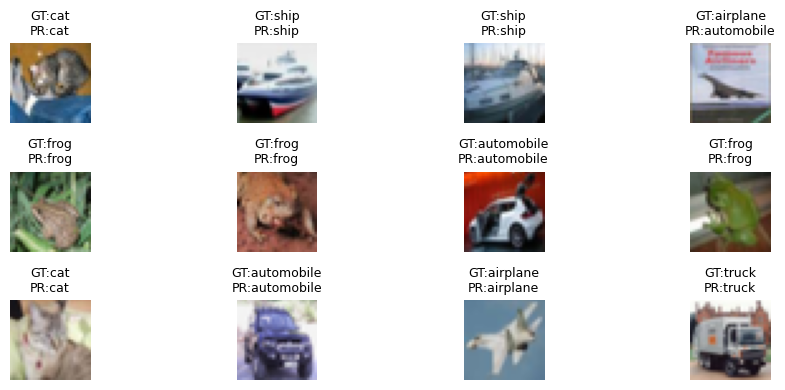

In [ ]:
@torch.no_grad()
def show_predictions(model: nn.Module, loader: DataLoader, classes, n: int = 12):
    model.eval()
    x, y = next(iter(loader))
    x = x.to(device)
    logits = model(x)
    preds = logits.argmax(dim=1).cpu()

    plt.figure(figsize=(10, 4))
    for i in range(n):
        plt.subplot(3, 4, i+1)
        img = denormalize(x[i].cpu()).clamp(0, 1)
        plt.imshow(img.permute(1,2,0))
        gt = classes[y[i].item()]
        pr = classes[preds[i].item()]
        plt.title(f"GT:{gt}\nPR:{pr}", fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_predictions(best_model, test_loader, classes, n=12)
